# **Day 52: Recommender Systems and Association Rules**
*Module 8 - Unsupervised Learning*

Recommenders decide what we see on YouTube, Amazon and Netflix; association rules find items bought together ("market-basket analysis"). Both learn from **co-occurrence patterns** in large, sparse interaction data. The same tools apply in science: which crops are grown together, which species co-occur, which datasets a researcher will need next.

> Recommender systems predict what a user will like from past behaviour, by finding similar users or items or hidden factors. Association rules find items that often occur together.
>
> *Example:* "Users who downloaded Sentinel-2 data for this area also downloaded the Copernicus DEM" is a recommendation based on co-occurrence.

In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)   # harmless numerical warnings (see text)
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
rng = np.random.default_rng(52)

## **1. Association Rules**
For a rule $A \Rightarrow B$ over transactions:
- **Support** $= P(A\cup B)$: how often A and B occur together
- **Confidence** $= P(B\mid A) = \frac{\text{support}(A\cup B)}{\text{support}(A)}$
- **Lift** $= \frac{\text{confidence}}{P(B)}$: >1 means A makes B more likely than its baseline (positive association)

Example: what farm inputs are bought together at a village agricultural store.

In [2]:
items = ["urea", "DAP", "potash", "rice_seed", "wheat_seed", "pesticide", "sprayer", "drip_kit", "veg_seed", "mulch"]
baskets = []
for _ in range(2000):
    b = set()
    if rng.random() < 0.55:
        b |= {"urea"}; b |= {"DAP"} if rng.random() < 0.7 else set()
        b |= {"rice_seed"} if rng.random() < 0.5 else set()
    if rng.random() < 0.25:
        b |= {"pesticide"}; b |= {"sprayer"} if rng.random() < 0.4 else set()
    if rng.random() < 0.12:
        b |= {"drip_kit", "veg_seed"}; b |= {"mulch"} if rng.random() < 0.6 else set()
    for it in items:
        if rng.random() < 0.05: b.add(it)
    if b: baskets.append(b)
onehot = pd.DataFrame([[it in b for it in items] for b in baskets], columns=items)
print(len(baskets), "transactions | item frequencies:\n", onehot.mean().sort_values(ascending=False).round(3).to_dict())

1629 transactions | item frequencies:
 {'urea': 0.68, 'DAP': 0.495, 'rice_seed': 0.389, 'pesticide': 0.36, 'veg_seed': 0.209, 'drip_kit': 0.207, 'sprayer': 0.177, 'mulch': 0.148, 'potash': 0.07, 'wheat_seed': 0.063}


### Apriori from scratch
**Apriori principle**: every subset of a frequent itemset is frequent, so we grow itemsets level by level and prune candidates that contain an infrequent subset.

In [3]:
def apriori(df, min_support=0.05):
    freq = {}; current = [frozenset([c]) for c in df.columns]
    k = 1
    while current:
        supports = {s: df[list(s)].all(axis=1).mean() for s in current}
        level = {s: v for s, v in supports.items() if v >= min_support}
        freq.update(level)
        keys = list(level); k += 1
        candidates = {a | b for a in keys for b in keys if len(a | b) == k}
        current = [c for c in candidates if all(frozenset(sub) in level for sub in combinations(c, k - 1))]   # prune
    return freq

def rules_from(freq, min_conf=0.5):
    rows = []
    for itemset, sup in freq.items():
        if len(itemset) < 2: continue
        for r_ in range(1, len(itemset)):
            for A in map(frozenset, combinations(itemset, r_)):
                B = itemset - A; conf = sup / freq[A]
                if conf >= min_conf:
                    rows.append({"antecedent": ", ".join(sorted(A)), "consequent": ", ".join(sorted(B)), "support": sup,
                                 "confidence": conf, "lift": conf / freq[B]})
    return pd.DataFrame(rows).sort_values("lift", ascending=False)

freq = apriori(onehot, 0.04)
rules = rules_from(freq, 0.5)
rules.head(10).round(3)

,antecedent,consequent,support,confidence,lift
73,"drip_kit, urea","DAP, veg_seed",0.059,0.522,6.488
76,"DAP, veg_seed","drip_kit, urea",0.059,0.733,6.488
75,"urea, veg_seed","DAP, drip_kit",0.059,0.527,6.365
74,"DAP, drip_kit","urea, veg_seed",0.059,0.711,6.365
98,"drip_kit, rice_seed","urea, veg_seed",0.044,0.686,6.138
99,"rice_seed, veg_seed","drip_kit, urea",0.044,0.692,6.129
81,"drip_kit, mulch","urea, veg_seed",0.052,0.538,4.815
87,"mulch, urea, veg_seed",drip_kit,0.052,0.988,4.763
85,"drip_kit, mulch, urea",veg_seed,0.052,0.988,4.735
60,"drip_kit, mulch",veg_seed,0.096,0.987,4.731


High **lift** rules (drip_kit -> veg_seed) reveal genuine bundles; high-confidence rules involving very common items (anything -> urea) can have lift ~1 and are uninformative.

## **2. A Ratings Dataset With Hidden Structure**
We simulate 300 users rating 120 items (1-5 stars). Each user and item has hidden **latent factors** (e.g. "likes vegetables", "prefers organic"); a rating = user factors . item factors + biases + noise. Only ~8% of ratings are observed (sparse, like real data).

In [4]:
n_users, n_items, k_true = 300, 120, 3
U_true = rng.normal(0, 1, (n_users, k_true)); V_true = rng.normal(0, 1, (n_items, k_true))
b_u = rng.normal(0, 0.4, n_users); b_i = rng.normal(0, 0.5, n_items)
full = np.clip(3.4 + b_u[:, None] + b_i[None, :] + 0.6 * U_true @ V_true.T + rng.normal(0, 0.4, (n_users, n_items)), 1, 5)
mask = rng.random((n_users, n_items)) < 0.08
obs = np.argwhere(mask)
ratings = pd.DataFrame({"user": obs[:, 0], "item": obs[:, 1], "rating": full[mask].round()})
test_idx = rng.random(len(ratings)) < 0.2
train_r, test_r = ratings[~test_idx], ratings[test_idx]
print(f"{len(ratings)} ratings ({mask.mean():.1%} of the matrix) | train {len(train_r)} | test {len(test_r)}")
R = np.full((n_users, n_items), np.nan); R[train_r.user, train_r.item] = train_r.rating
rmse = lambda p, t: np.sqrt(np.mean((p - t) ** 2))

2913 ratings (8.1% of the matrix) | train 2315 | test 598


## **3. Baselines**

In [5]:
mu = train_r.rating.mean()
item_mean = train_r.groupby("item").rating.mean(); user_mean = train_r.groupby("user").rating.mean()
p_global = np.full(len(test_r), mu)
bu = (train_r.rating - mu).groupby(train_r.user).mean(); bi = (train_r.rating - mu - train_r.user.map(bu)).groupby(train_r.item).mean()
p_bias = mu + test_r.user.map(bu).fillna(0).values + test_r.item.map(bi).fillna(0).values
print(f"global mean RMSE {rmse(p_global, test_r.rating.values):.3f} | user + item bias RMSE {rmse(p_bias, test_r.rating.values):.3f}")

global mean RMSE 1.158 | user + item bias RMSE 1.121


## **4. Item-Based Collaborative Filtering**
Predict a user's rating of item $i$ from their ratings of items **similar** to $i$ (similarity computed from co-rating patterns, after removing user means).

In [6]:
n_rated = (~np.isnan(R)).sum(1)
user_mean = np.where(n_rated > 0, np.nansum(R, 1) / np.maximum(n_rated, 1), mu)       # users without training ratings -> global mean
Rc = R - user_mean[:, None]
Rz = np.nan_to_num(Rc)
norms = np.linalg.norm(Rz, axis=0) + 1e-9
item_sim = (Rz.T @ Rz) / np.outer(norms, norms)                                # cosine similarity between items
def predict_item_cf(u, i, k=20):
    rated = np.flatnonzero(~np.isnan(R[u]))
    if len(rated) == 0: return user_mean[u]
    sims = item_sim[i, rated]; top = np.argsort(sims)[::-1][:k]; s = sims[top]
    if np.abs(s).sum() < 1e-9: return user_mean[u]
    return user_mean[u] + (s * Rc[u, rated[top]]).sum() / np.abs(s).sum()
p_cf = np.clip([predict_item_cf(u, i) for u, i in zip(test_r.user, test_r.item)], 1, 5)
print(f"item-based CF RMSE {rmse(p_cf, test_r.rating.values):.3f}")

item-based CF RMSE 1.180


## **5. Matrix Factorisation (Funk SVD)**
Learn user vectors $\mathbf p_u$ and item vectors $\mathbf q_i$ (k latent factors) plus biases so that $\hat r_{ui} = \mu + b_u + b_i + \mathbf p_u^\top\mathbf q_i$, minimising squared error **on observed ratings only**, with L2 regularisation. Trained by SGD (Koren et al., 2009, the Netflix Prize approach).

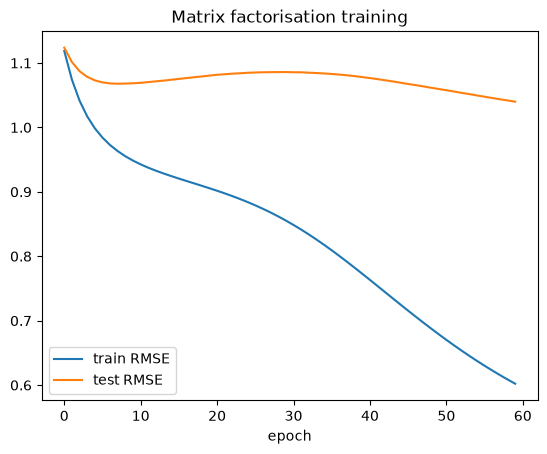

matrix factorisation (k=3) test RMSE 1.040


In [7]:
def train_mf(train, n_users, n_items, k=5, lr=0.01, reg=0.05, epochs=60, seed=0):
    r = np.random.default_rng(seed)
    P = r.normal(0, 0.1, (n_users, k)); Q = r.normal(0, 0.1, (n_items, k)); bu = np.zeros(n_users); bi = np.zeros(n_items)
    mu_ = train.rating.mean(); data = train[["user", "item", "rating"]].values; hist = []
    for ep in range(epochs):
        for idx in r.permutation(len(data)):
            u, i, rt = int(data[idx, 0]), int(data[idx, 1]), data[idx, 2]
            e = rt - (mu_ + bu[u] + bi[i] + P[u] @ Q[i])
            bu[u] += lr * (e - reg * bu[u]); bi[i] += lr * (e - reg * bi[i])
            P[u], Q[i] = P[u] + lr * (e * Q[i] - reg * P[u]), Q[i] + lr * (e * P[u] - reg * Q[i])
        pred = lambda df: np.clip(mu_ + bu[df.user] + bi[df.item] + (P[df.user] * Q[df.item]).sum(1), 1, 5)
        hist.append((rmse(pred(train), train.rating.values), rmse(pred(test_r), test_r.rating.values)))
    return pred, np.array(hist), P, Q

pred_mf, hist, P, Q = train_mf(train_r, n_users, n_items, k=3)
plt.plot(hist[:, 0], label="train RMSE"); plt.plot(hist[:, 1], label="test RMSE"); plt.xlabel("epoch"); plt.legend(); plt.title("Matrix factorisation training"); plt.show()
print(f"matrix factorisation (k=3) test RMSE {hist[-1, 1]:.3f}")

### Effect of the number of factors and regularisation

In [8]:
res = {}
for k in [1, 3, 10]:
    for reg in [0.0, 0.05, 0.2]:
        res[(k, reg)] = train_mf(train_r, n_users, n_items, k=k, reg=reg, epochs=40)[1][-1, 1]
pd.Series(res).unstack().round(3).rename_axis(index="k factors", columns="L2 reg")

L2 reg,0.00,0.05,0.20
k factors,,,
1,1.111,1.100,1.082
3,1.085,1.078,1.075
10,1.062,1.059,1.067


## **6. Ranking Evaluation: Precision@k**
Users see a **top-k list**, so ranking quality matters more than RMSE. For each user, recommend the k highest-predicted **unseen** items and check how many are "relevant" (true rating >= 4) among the held-out items.

In [9]:
def precision_at_k(pred_fn, k=5):
    precs = []
    for u, grp in test_r.groupby("user"):
        if len(grp) < k: continue
        df_u = pd.DataFrame({"user": u, "item": grp.item.values})
        top = grp.item.values[np.argsort(pred_fn(df_u))[::-1][:k]]
        relevant = set(grp.item[grp.rating >= 4])
        precs.append(len(set(top) & relevant) / k)
    return np.mean(precs)
popular = train_r.groupby("item").rating.count()
pop_fn = lambda df: df.item.map(popular).fillna(0).values
rand_fn = lambda df: rng.random(len(df))
print(f"precision@5: random {precision_at_k(rand_fn):.3f} | popularity {precision_at_k(pop_fn):.3f} | matrix factorisation {precision_at_k(pred_mf):.3f}")

precision@5: random 0.380 | popularity 0.420 | matrix factorisation 0.440


# **Part 2: Going Deeper**

### Latent factors are interpretable-ish
The learned item vectors $\mathbf q_i$ span (approximately) the same space as the true hidden factors. Check with a linear regression from learned to true factors.

In [10]:
from sklearn.linear_model import LinearRegression
r2 = [LinearRegression().fit(Q, V_true[:, j]).score(Q, V_true[:, j]) for j in range(k_true)]
print("R2 of each true item factor explained by the learned factors:", np.round(r2, 3))

R2 of each true item factor explained by the learned factors: [0.527 0.555 0.127]


### Practical issues
- **Cold start**: new users/items have no ratings -> use content features (item descriptions, user profile) or popularity; hybrid models.
- **Implicit feedback** (clicks, views, purchases) has no negatives: use weighted matrix factorisation / ALS (Hu et al., 2008) or ranking losses (BPR).
- **Popularity bias and feedback loops**: recommending popular items makes them more popular; evaluate diversity and coverage too.
- **Modern systems**: two-tower neural networks, sequence models (transformers) on interaction histories.

### Truncated SVD on the mean-filled matrix (quick baseline)

In [11]:
from sklearn.decomposition import TruncatedSVD
filled = np.where(np.isnan(R), 0, Rc)
svd = TruncatedSVD(3, random_state=0).fit(filled)
recon = svd.inverse_transform(svd.transform(filled)) + user_mean[:, None]
print(f"truncated SVD (k=3) test RMSE {rmse(np.clip(recon[test_r.user, test_r.item], 1, 5), test_r.rating.values):.3f}  (treating missing as 0 biases it)")

truncated SVD (k=3) test RMSE 1.147  (treating missing as 0 biases it)


## **Practice Problems**
1. Re-run Apriori with `min_support=0.02`. Which new rules with lift > 3 appear?
2. Implement **user-based** CF (similar users instead of similar items) and compare RMSE.
3. Train MF with k = 3 for 150 epochs without regularisation. What happens to test RMSE (overfitting)?
4. *(Advanced)* Implement **Alternating Least Squares**: fix Q and solve a ridge regression for each user's $\mathbf p_u$, then fix P and solve for each $\mathbf q_i$ (ignore biases; centre ratings by the global mean).

In [12]:
# Solution 1
r2_ = rules_from(apriori(onehot, 0.02), 0.5); print(r2_[r2_.lift > 3].head(8).round(3))
# Solution 2
norms_u = np.linalg.norm(Rz, axis=1) + 1e-9; user_sim = (Rz @ Rz.T) / np.outer(norms_u, norms_u)
def predict_user_cf(u, i, k=30):
    raters = np.flatnonzero(~np.isnan(R[:, i]))
    if len(raters) == 0: return user_mean[u]
    s = user_sim[u, raters]; top = np.argsort(s)[::-1][:k]
    return user_mean[u] + (s[top] * Rc[raters[top], i]).sum() / (np.abs(s[top]).sum() + 1e-9)
p_ucf = np.clip([predict_user_cf(u, i) for u, i in zip(test_r.user, test_r.item)], 1, 5)
print(f"user-based CF RMSE {rmse(p_ucf, test_r.rating.values):.3f}")
# Solution 3
h_noreg = train_mf(train_r, n_users, n_items, k=3, reg=0.0, epochs=150)[1]
print(f"no regularisation: best test RMSE {h_noreg[:, 1].min():.3f} at epoch {h_noreg[:, 1].argmin()} | final {h_noreg[-1, 1]:.3f}")
# Solution 4
def als(train, k=3, lam=1.0, iters=15, seed=0):
    r = np.random.default_rng(seed); mu_ = train.rating.mean()
    P = r.normal(0, 0.1, (n_users, k)); Q = r.normal(0, 0.1, (n_items, k))
    by_u = {u: g for u, g in train.groupby("user")}; by_i = {i: g for i, g in train.groupby("item")}
    for _ in range(iters):
        for u, g in by_u.items():
            Qi = Q[g.item.values]; P[u] = np.linalg.solve(Qi.T @ Qi + lam * np.eye(k), Qi.T @ (g.rating.values - mu_))
        for i, g in by_i.items():
            Pu = P[g.user.values]; Q[i] = np.linalg.solve(Pu.T @ Pu + lam * np.eye(k), Pu.T @ (g.rating.values - mu_))
    return lambda df: np.clip(mu_ + (P[df.user] * Q[df.item]).sum(1), 1, 5)
print(f"ALS test RMSE {rmse(als(train_r)(test_r), test_r.rating.values):.3f}")

                     antecedent           consequent  support  confidence  \
114           drip_kit, sprayer  pesticide, veg_seed    0.021       0.700   
115           sprayer, veg_seed  drip_kit, pesticide    0.021       0.729   
225        DAP, mulch, veg_seed       drip_kit, urea    0.036       0.967   
221       drip_kit, mulch, urea        DAP, veg_seed    0.036       0.686   
222        DAP, drip_kit, mulch       urea, veg_seed    0.036       0.952   
224       mulch, urea, veg_seed        DAP, drip_kit    0.036       0.686   
234  drip_kit, mulch, rice_seed       urea, veg_seed    0.027       0.917   
233       drip_kit, mulch, urea  rice_seed, veg_seed    0.027       0.512   

       lift  
114  11.403  
115  11.101  
225   8.563  
221   8.531  
222   8.517  
224   8.278  
234   8.205  
233   8.014  
user-based CF RMSE 1.127


no regularisation: best test RMSE 1.051 at epoch 90 | final 1.069


ALS test RMSE 1.106


## **Key References**
- Agrawal, R., & Srikant, R. (1994). Fast algorithms for mining association rules. *VLDB 1994*, 487-499.
- Sarwar, B., Karypis, G., Konstan, J., & Riedl, J. (2001). Item-based collaborative filtering recommendation algorithms. *WWW 2001*, 285-295.
- Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. *Computer*, 42(8), 30-37.
- Hu, Y., Koren, Y., & Volinsky, C. (2008). Collaborative filtering for implicit feedback datasets. *IEEE ICDM 2008*, 263-272.
- Rendle, S., Freudenthaler, C., Gantner, Z., & Schmidt-Thieme, L. (2009). BPR: Bayesian personalized ranking from implicit feedback. *UAI 2009*.